# FlashEats — Class 5 Investigation

## Client escalation

> **“Late deliveries are increasing and customers say our ETA is unreliable. Figure out what is happening before we invest in an AI delay-prediction system.”**

Today is not a syntax lesson. Your job is to use SQL, CSV, JSON and APIs like an FDE:

**define the question → retrieve evidence → validate completeness → reconcile sources → state what you know and what you still cannot know**

### Rules
- Do not train an ML model.
- State your definition of **late** before calculating it.
- Preserve raw API responses.
- Do not silently drop failures.
- If another team gets a different answer, investigate the definition and data grain first.

In [1]:
import os, json, sqlite3
from pathlib import Path
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 200)


def find_pack_root():
    """Pack root = folder with database/flasheats.db AND the Class 6/7 files (the updated instructor pack).

    Search order: $FLASHEATS_PACK, Challenges/flasheats-classroom-pack (created by get_pack.sh),
    the working directory and its parents, ~/flasheats-classroom-pack, then the Colab location.
    """
    candidates = [Path(os.environ["FLASHEATS_PACK"])] if os.environ.get("FLASHEATS_PACK") else []
    candidates += [Path.cwd() / "flasheats-classroom-pack", Path.cwd() / "Challenges" / "flasheats-classroom-pack",
                   Path.cwd(), *Path.cwd().parents, Path.home() / "flasheats-classroom-pack",
                   Path("/content/FlashEats_Classroom_Pack")]
    for folder in candidates:
        if (folder / "database" / "flasheats.db").exists() and (folder / "data" / "order_outcomes.csv").exists():
            return folder
    raise FileNotFoundError("FlashEats pack not found. Run `bash Challenges/get_pack.sh` or set FLASHEATS_PACK.")


BASE = find_pack_root()
OUTPUT = Path.cwd() / "output" if (Path.cwd() / "get_pack.sh").exists() else Path.cwd() / "Challenges" / "output"
OUTPUT.mkdir(parents=True, exist_ok=True)
print("Pack:", os.path.relpath(BASE))

import sys, time, subprocess
import requests
import matplotlib.pyplot as plt
# Dependencies: pip install -r Challenges/requirements.txt  (no ML libraries, per the class rules)

Pack: flasheats-classroom-pack


## 2. Source map first

Before analysis, predict where you would look for:

| Information | Likely source | Why? |
|---|---|---|
| Promised delivery time |  |  |
| Actual delivery time |  |  |
| Driver assignment |  |  |
| Customer complaint |  |  |
| Restaurant status |  |  |
| Driver movement/events |  |  |

**Discuss:** Which source is authoritative for each fact, and which is only contextual?

### Our source map

| Information | Likely source | Why? | Authoritative or contextual? |
|---|---|---|---|
| Promised delivery time | `orders.promised_eta` (SQLite) | Set at checkout by the order platform | **Authoritative** for the promise. Dispatch's `current_delivery_eta` is a *revised* ETA, not the promise. |
| Actual delivery time | `orders.actual_delivery_at` | Order platform completion record | **Authoritative**, but 37 delivered orders are missing it; `driver_events.delivered` is a second, matching source. |
| Driver assignment | Dispatch API (`driver_id`, `original_driver_id`, `assigned_at`, `reassigned_at`) | Dispatch owns assignment | **Authoritative** for assignment and reassignment; `orders.driver_id` is only the final driver. |
| Customer complaint | `support_tickets.csv` | Support system | **Authoritative** for what customers *said*, contextual for *why* the order was late. |
| Restaurant status | `restaurant_status.csv` | Restaurant tablet / manual updates | **Contextual**: manually updated, minute-rounded, can lag. |
| Driver movement/events | `driver_events.json` | Driver app | **Observed** for assigned / picked_up / delivered taps, **inferred-only** for location (GPS pings about every 13 min). |

In [2]:
# 3. BASIC SYNTAX — READ EVERY SOURCE

# SQLite
db_path = BASE / "database" / "flasheats.db"
con = sqlite3.connect(db_path)

tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;",
    con
)
display(tables)

sample_orders = pd.read_sql("SELECT * FROM orders LIMIT 5;", con)
display(sample_orders)

# CSV
tickets = pd.read_csv(BASE / "data" / "support_tickets.csv")
restaurant_status = pd.read_csv(BASE / "data" / "restaurant_status.csv")
display(tickets.head())

# Nested JSON
with open(BASE / "data" / "driver_events.json", "r") as f:
    driver_events = json.load(f)

print("Driver objects:", len(driver_events))
display(driver_events[:1])

,name
0,customers
1,drivers
2,orders
3,restaurants


,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
0,O00001,C0168,R009,D103,Bengaluru,2026-08-13T12:56:00,2026-08-13T14:11:36,2026-08-13T13:35:49.825561,2026-08-13T14:22:25.035899,delivered,18.00,medium,clear
1,O00002,C0043,R018,D083,Bengaluru,2026-08-01T18:36:00,2026-08-01T19:43:16.627988,2026-08-01T18:58:24.735336,2026-08-01T19:47:14.818533,delivered,9.37,severe,clear
2,O00003,C0855,R010,D039,Bengaluru,2026-08-01T19:35:00,2026-08-01T20:17:52.941967,2026-08-01T19:57:50.820366,2026-08-01T20:13:28.061191,delivered,2.42,medium,clear
3,O00004,C0229,R030,D038,Bengaluru,2026-08-09T18:16:00,2026-08-09T19:30:19.067006,2026-08-09T18:46:48.725485,NaN,cancelled,14.20,high,rain
4,O00005,C0040,R004,D047,Bengaluru,2026-08-06T20:35:00,2026-08-06T21:54:48,2026-08-06T21:18:38.024280,2026-08-06T22:15:49.290713,delivered,18.00,high,clear


,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


Driver objects: 120


[{'driver_id': 'D001',
  'events': [{'order_id': 'O00162',
    'type': 'assigned',
    'timestamp': '2026-08-26T17:53:25.977803'},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:10:59.372420',
    'lat': 12.826339,
    'lon': 77.448282},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:28:32.767037',
    'lat': 12.876013,
    'lon': 77.477707},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:46:06.161653',
    'lat': 12.925686,
    'lon': 77.507133},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T19:03:39.556270',
    'lat': 12.97536,
    'lon': 77.536558},
   {'order_id': 'O00162',
    'type': 'picked_up',
    'timestamp': '2026-08-26T18:27:32.131791'},
   {'order_id': 'O00162',
    'type': 'delivered',
    'timestamp': '2026-08-26T19:21:12.950887'},
   {'order_id': 'O00180',
    'type': 'assigned',
    'timestamp': '2026-08-08T18:05:08.439625'},
   {'o

# Challenge 1 — How large is the late-delivery problem?

Before coding, decide:

- **Late means:** ______________________________
- **Denominator:** _____________________________
- **Cancelled orders:** include / exclude / other?
- **Missing actual delivery timestamp:** what will you do?
- **Row grain:** what does one row represent?

### Required analysis
1. valid delivered orders,
2. late count and percentage,
3. median lateness among late orders,
4. worst delayed orders,
5. any data-quality issue that changes the metric.

### Our decisions (written before querying)

- **Late means:** `actual_delivery_at > promised_eta`, i.e. any delay above 0 minutes. The promise the customer saw is the contract; a threshold such as +10 min would be a business choice, reported as a sensitivity.
- **Denominator:** unique orders whose status is *delivered* (case-insensitive) **and** that have a recorded delivery time.
- **Cancelled orders:** excluded from the late rate (they have no delivery to be late), and counted and reported separately.
- **Missing actual delivery timestamp:** excluded from the rate but **reported as "unknown"**, with the best-case and worst-case effect shown. They are never silently dropped.
- **Row grain:** one row should be one order. We test that assumption instead of trusting it.

In [3]:
raw_orders = pd.read_sql("SELECT * FROM orders", con)
print("rows:", len(raw_orders), "| unique order_id:", raw_orders["order_id"].nunique())

# Grain check: duplicate order_ids — are they exact copies or conflicting records?
dups = raw_orders[raw_orders["order_id"].duplicated(keep=False)].sort_values("order_id")
display(dups[["order_id", "created_at", "promised_eta", "actual_delivery_at", "final_status", "traffic_bucket"]])

orders = raw_orders.copy()
for col in ["created_at", "promised_eta", "pickup_at", "actual_delivery_at"]:
    orders[col] = pd.to_datetime(orders[col], format="mixed", errors="coerce")
orders["status_norm"] = orders["final_status"].str.strip().str.lower()        # "Delivered" -> "delivered" (representation)
orders["traffic_norm"] = orders["traffic_bucket"].str.strip().str.lower()     # "HIGH" -> "high" (representation)
print("final_status values:", raw_orders["final_status"].value_counts().to_dict())

# The duplicates share every timestamp, so keeping the first row cannot change lateness; the conflicting
# traffic_bucket is recorded as an open question, not resolved by guessing.
orders = orders.drop_duplicates("order_id", keep="first")
orders["delay_min"] = (orders["actual_delivery_at"] - orders["promised_eta"]).dt.total_seconds() / 60

delivered = orders[orders["status_norm"] == "delivered"]
valid = delivered[delivered["actual_delivery_at"].notna()]
late = valid[valid["delay_min"] > 0]

summary = pd.Series({
    "unique orders": len(orders),
    "cancelled (excluded)": int((orders["status_norm"] == "cancelled").sum()),
    "delivered": len(delivered),
    "delivered but missing actual_delivery_at (unknown)": int(delivered["actual_delivery_at"].isna().sum()),
    "valid delivered orders (denominator)": len(valid),
    "late orders": len(late),
    "late rate %": round(100 * len(late) / len(valid), 1),
    "late rate % if every unknown was late (worst case)": round(100 * (len(late) + delivered["actual_delivery_at"].isna().sum()) / len(delivered), 1),
    "late rate % if every unknown was on time (best case)": round(100 * len(late) / len(delivered), 1),
    "median lateness of late orders (min)": round(late["delay_min"].median(), 1),
    "P90 lateness of late orders (min)": round(late["delay_min"].quantile(0.9), 1),
})
display(summary.to_frame("value"))

rows: 1603 | unique order_id: 1600


,order_id,created_at,promised_eta,actual_delivery_at,final_status,traffic_bucket
119,O00120,2026-08-13T18:15:00,2026-08-13T19:40:24,2026-08-13T19:34:08.431508,delivered,severe
1600,O00120,2026-08-13T18:15:00,2026-08-13T19:40:24,2026-08-13T19:34:08.431508,delivered,medium
722,O00723,2026-08-05T21:04:00,2026-08-05T22:19:36,2026-08-05T22:04:30.928322,delivered,medium
1601,O00723,2026-08-05T21:04:00,2026-08-05T22:19:36,2026-08-05T22:04:30.928322,delivered,high
1301,O01302,2026-08-26T21:07:00,2026-08-26T22:15:50.273095,2026-08-26T22:20:27.428561,delivered,medium
1602,O01302,2026-08-26T21:07:00,2026-08-26T22:15:50.273095,2026-08-26T22:20:27.428561,delivered,high


final_status values: {'delivered': 1530, 'cancelled': 68, 'Delivered': 5}


,value
unique orders,1600.0
cancelled (excluded),68.0
delivered,1532.0
delivered but missing actual_delivery_at (unknown),37.0
valid delivered orders (denominator),1495.0
late orders,843.0
late rate %,56.4
late rate % if every unknown was late (worst case),57.4
late rate % if every unknown was on time (best case),55.0
median lateness of late orders (min),8.0


In [4]:
# Worst delayed orders — and a data-quality check on them before anyone quotes them.
worst = valid.nlargest(6, "delay_min")[["order_id", "created_at", "promised_eta", "pickup_at", "actual_delivery_at", "delay_min"]]
worst["eta_before_order_created"] = worst["promised_eta"] < worst["created_at"]
display(worst)

chronology = pd.Series({
    "promised_eta earlier than created_at": int((orders["promised_eta"] < orders["created_at"]).sum()),
    "actual_delivery_at earlier than pickup_at": int((orders["actual_delivery_at"] < orders["pickup_at"]).sum()),
})
display(chronology.to_frame("orders"))
clean = valid[(valid["promised_eta"] >= valid["created_at"]) & (valid["actual_delivery_at"] >= valid["pickup_at"])]
print(f"Late rate excluding the {len(valid) - len(clean)} chronology-broken orders: {100 * (clean['delay_min'] > 0).mean():.1f}%")

,order_id,created_at,promised_eta,pickup_at,actual_delivery_at,delay_min,eta_before_order_created
103,O00104,2026-08-09 22:19:00,2026-08-09 22:09:00.000000,2026-08-09 22:47:33.934776,2026-08-09 23:36:20.740161,87.345669,True
101,O00102,2026-08-11 16:41:00,2026-08-11 16:31:00.000000,2026-08-11 17:05:05.809584,2026-08-11 17:57:17.661772,86.294363,True
100,O00101,2026-08-24 20:59:00,2026-08-24 20:49:00.000000,2026-08-24 21:25:03.983984,2026-08-24 22:14:30.685278,85.511421,True
102,O00103,2026-08-22 20:11:00,2026-08-22 20:01:00.000000,2026-08-22 20:39:45.064627,2026-08-22 21:10:17.342305,69.289038,True
1080,O01081,2026-08-13 17:14:00,2026-08-13 18:15:46.613098,2026-08-13 18:19:53.467196,2026-08-13 19:06:02.677891,50.267747,False
472,O00473,2026-08-14 18:58:00,2026-08-14 20:17:48.000000,2026-08-14 20:05:22.631148,2026-08-14 21:04:00.769224,46.212820,False


,orders
promised_eta earlier than created_at,4
actual_delivery_at earlier than pickup_at,5


Late rate excluding the 9 chronology-broken orders: 56.3%


### Challenge 1 findings

- **Problem size:** **843 of 1,495** valid delivered orders were late: **56.4%**. The **median lateness of a late order is 8.0 minutes** (P90 22.3 min).
- **The 37 delivered orders with no delivery time** move the rate between **55.0% and 57.4%**, so we report it as a range until they are resolved.
- **Data-quality issues that change the metric:**
  1. **3 duplicate `order_id`s** (O00120, O00723, O01302) with *different* `traffic_bucket` values. They are conflicting records, not copies. Without de-duplication the denominator is inflated.
  2. **5 orders are `"Delivered"`** (capital D). An exact `= 'delivered'` filter silently drops them.
  3. **The 4 "worst" late orders (O00101–O00104, 69–87 min late) are data errors.** Their promised ETA is 10 minutes *before* the order was created. The real worst genuine delay is O01081 at 50.3 min.
  4. **5 orders were delivered 5 minutes *before* they were picked up** (O00051–O00055), a clock or event-order problem.
- Excluding the 9 chronology-broken orders barely moves the rate (56.3%), but it completely changes the "worst orders" list anyone would escalate.

## Checkpoint

Compare your answer with another team.

If your counts differ, investigate:
- duplicate rows,
- cancelled orders,
- missing timestamps,
- late-delivery definition,
- row grain.

In [5]:
# What another team gets with the "obvious" SQL: exact status match, no de-duplication.
naive = pd.read_sql("""
SELECT COUNT(*) AS delivered_rows,
       SUM(CASE WHEN datetime(actual_delivery_at) > datetime(promised_eta) THEN 1 ELSE 0 END) AS late_rows
FROM orders
WHERE final_status = 'delivered' AND actual_delivery_at IS NOT NULL
""", con)
naive["late_rate_%"] = (100 * naive["late_rows"] / naive["delivered_rows"]).round(2)
display(naive)

,delivered_rows,late_rows,late_rate_%
0,1493,841,56.33


**Why the teams differ.** The naive query returns 841 / 1,493 = **56.33%**; ours is 843 / 1,495 = **56.39%**. The totals look alike, but they hide two opposite errors:
- The naive query **counts 3 duplicate rows**.
- It also **misses 5 `"Delivered"` orders**.

The errors happen to almost cancel today. They would not on another day. Always reconcile row grain and category representation before comparing rates.

# Challenge 2 — Operations says: “Traffic is the problem.”

Test that claim using at least three dimensions.

Possible dimensions:
- traffic,
- weather,
- distance,
- time of day,
- restaurant,
- driver.

### Required output
- 2–3 comparisons,
- one chart or compact table,
- one hypothesis supported by evidence,
- one alternative explanation you cannot rule out.

Separate **association** from **causation**.

In [6]:
v = clean.copy()
v["late"] = v["delay_min"] > 0
v["prep_stage_min"] = (v["pickup_at"] - v["created_at"]).dt.total_seconds() / 60       # order -> pickup
v["travel_stage_min"] = (v["actual_delivery_at"] - v["pickup_at"]).dt.total_seconds() / 60  # pickup -> door
v["promised_min"] = (v["promised_eta"] - v["created_at"]).dt.total_seconds() / 60
v["distance_band"] = pd.cut(v["distance_km_estimate"], [0, 6, 10, 15, 100], labels=["0-6 km", "6-10 km", "10-15 km", "15+ km"])
v["time_of_day"] = pd.cut(v["created_at"].dt.hour, [0, 15, 18, 21, 24], right=False,
                          labels=["before 15:00", "15-18", "18-21", "21-24"])

def compare(dim):
    return (v.groupby(dim, observed=True)
             .agg(orders=("late", "size"), late_rate=("late", "mean"), median_delay_min=("delay_min", "median"),
                  promised_min=("promised_min", "median"), travel_min=("travel_stage_min", "median"),
                  prep_min=("prep_stage_min", "median"))
             .round(2))

for dim in ["traffic_norm", "weather_bucket", "distance_band", "time_of_day"]:
    print("\n==", dim); display(compare(dim))


== traffic_norm


,orders,late_rate,median_delay_min,promised_min,travel_min,prep_min
traffic_norm,,,,,,
high,421,0.67,3.96,79.8,53.08,26.94
low,358,0.49,-0.09,72.8,43.48,25.71
medium,585,0.51,0.21,75.6,46.73,25.87
severe,122,0.66,4.27,85.4,61.87,25.53



== weather_bucket


,orders,late_rate,median_delay_min,promised_min,travel_min,prep_min
weather_bucket,,,,,,
clear,1185,0.53,0.77,72.80,46.01,26.07
heavy_rain,72,0.74,6.63,81.45,60.02,24.78
rain,229,0.67,4.23,75.30,51.96,26.53



== distance_band


,orders,late_rate,median_delay_min,promised_min,travel_min,prep_min
distance_band,,,,,,
0-6 km,96,0.51,0.26,47.07,21.82,24.85
6-10 km,193,0.57,1.70,57.01,32.17,25.67
10-15 km,300,0.53,0.64,65.85,40.49,26.60
15+ km,897,0.58,1.73,75.60,51.78,26.13



== time_of_day


,orders,late_rate,median_delay_min,promised_min,travel_min,prep_min
time_of_day,,,,,,
before 15:00,383,0.56,1.18,73.54,48.56,26.07
15-18,258,0.60,3.06,72.80,47.19,27.19
18-21,597,0.57,1.52,72.80,47.12,25.95
21-24,248,0.52,0.93,72.80,45.28,24.98


,prep_stage_min,travel_stage_min,promised_min,distance_km_estimate
on time,19.8,45.3,72.8,17.9
late,31.9,49.0,74.3,18.0


correlation with delay_min: {'prep_stage_min': 0.94, 'travel_stage_min': 0.23, 'distance_km_estimate': 0.07}


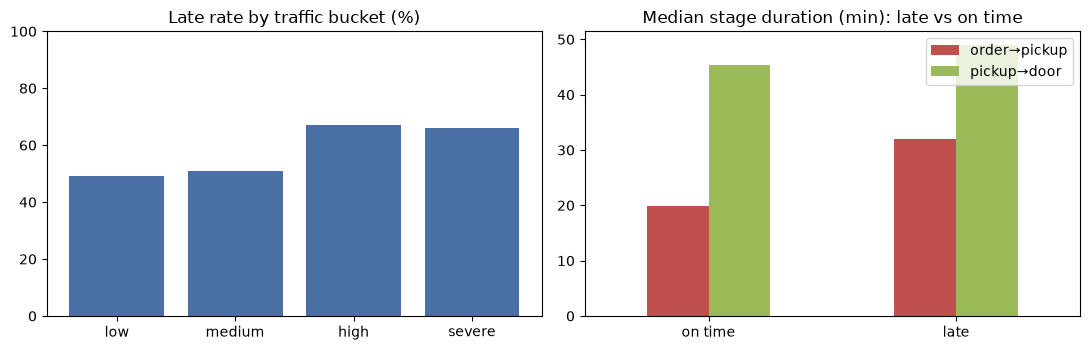

In [7]:
# Where does the delay accumulate? Compare the two stages for late vs on-time orders.
stage = v.groupby("late")[["prep_stage_min", "travel_stage_min", "promised_min", "distance_km_estimate"]].median().round(1)
stage.index = ["on time", "late"]
display(stage)
print("correlation with delay_min:",
      v[["prep_stage_min", "travel_stage_min", "distance_km_estimate"]].corrwith(v["delay_min"]).round(2).to_dict())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
t = compare("traffic_norm").reindex(["low", "medium", "high", "severe"])
axes[0].bar(t.index, 100 * t["late_rate"], color="#4a6fa5")
axes[0].set_title("Late rate by traffic bucket (%)"); axes[0].set_ylim(0, 100)
stage[["prep_stage_min", "travel_stage_min"]].plot(kind="bar", ax=axes[1], color=["#c0504d", "#9bbb59"], rot=0)
axes[1].set_title("Median stage duration (min): late vs on time"); axes[1].legend(["order→pickup", "pickup→door"])
plt.tight_layout(); plt.show()

### Challenge 2 findings — traffic is associated with lateness, but it is not where most of the delay sits

| Comparison | What the data shows |
|---|---|
| Traffic | Late rate **49% (low) → 51% (medium) → 67% (high) / 66% (severe)**. There is an association, but the promised ETA already grows with traffic (median promise 72.8 → 85.4 min), so traffic is partly priced into the promise. |
| Weather | **53% (clear) → 67% (rain) → 74% (heavy rain)**. Travel time rises with rain (46 → 60 min). |
| Distance | Flat: **51–58% in every band**. Longer trips get longer promises. |
| Time of day | Flat: **52–60%**. |
| **Stage split** | Late orders spend a median **31.9 min from order to pickup** vs **19.8 min** for on-time orders; the road stage differs much less (**49.0 vs 45.3 min**). Delay correlates **0.94** with the order-to-pickup stage and only **0.23** with the travel stage. |

- **Hypothesis supported by the evidence:** most lateness accumulates **before pickup** (restaurant preparation and/or the driver reaching the restaurant). Traffic and rain add to it, but the promise already absorbs part of that.
- **Alternative explanation we cannot rule out:**
  - The order-to-pickup stage mixes two very different things: *food not ready* and *driver not there yet*. Without a "driver arrived at restaurant" event (Challenge 5), we cannot say whose delay it is.
  - Traffic can also delay the driver's trip *to* the restaurant, which would show up in that same stage.
- **Association, not causation.** These are observational comparisons. Busy, rainy evenings stack several factors at once.

# Challenge 3 — Customer Support disagrees

Use `support_tickets.csv`.

### Questions
1. What are customers actually complaining about?
2. Which complaint types are most common?
3. Are ticket IDs unique?
4. Does the customer story match the operational story?
5. What can tickets tell you that timestamps cannot?

### Required output
A short **system view vs customer view** comparison.

In [8]:
tickets = pd.read_csv(BASE / "data" / "support_tickets.csv")
print("rows:", len(tickets), "| unique ticket_id:", tickets["ticket_id"].nunique(),
      "| exact duplicate rows:", int(tickets.duplicated().sum()), "| tickets with no order_id:", int(tickets["order_id"].isna().sum()))
display(tickets[tickets["ticket_id"].duplicated(keep=False)])

tickets = tickets.drop_duplicates()                                                   # exact copy -> safe to drop
tickets["category_norm"] = tickets["category"].str.strip().str.lower().str.replace(" ", "_")
print("raw category spellings:", tickets["category"].value_counts().to_dict())

outcome = orders[["order_id", "status_norm", "delay_min", "actual_delivery_at"]].copy()
outcome["order_outcome"] = "on_time"
outcome.loc[outcome["delay_min"] > 0, "order_outcome"] = "late"
outcome.loc[outcome["actual_delivery_at"].isna(), "order_outcome"] = "unknown_time"
outcome.loc[outcome["status_norm"] == "cancelled", "order_outcome"] = "cancelled"

tv = tickets.merge(outcome, on="order_id", how="left")
tv["order_outcome"] = tv["order_outcome"].fillna("no order link")
display(pd.crosstab(tv["category_norm"], tv["order_outcome"], margins=True))

rate = outcome.assign(ticket=outcome["order_id"].isin(tickets["order_id"])).groupby("order_outcome")["ticket"].agg(["sum", "mean"])
rate.columns = ["orders_with_ticket", "ticket_rate"]
display(rate.round(3))

rows: 202 | unique ticket_id: 201 | exact duplicate rows: 1 | tickets with no order_id: 3


,ticket_id,order_id,created_at,category,customer_message
12,T00013,O00090,2026-08-20T18:14:00,late_delivery,My order is already past the promised time.
201,T00013,O00090,2026-08-20T18:14:00,late_delivery,My order is already past the promised time.


raw category spellings: {'late_delivery': 37, 'eta_changed': 37, 'restaurant_delay': 37, 'ready_but_waiting': 33, 'status_mismatch': 29, 'driver_not_moving': 25, 'Late Delivery': 1, 'late_delivery ': 1, 'ETA issue': 1}


order_outcome,late,no order link,on_time,unknown_time,All
category_norm,,,,,
driver_not_moving,17,0,8,0,25
eta_changed,28,1,7,1,37
eta_issue,1,0,0,0,1
late_delivery,33,1,5,0,39
ready_but_waiting,30,0,3,0,33
restaurant_delay,28,0,9,0,37
status_mismatch,26,1,2,0,29
All,163,3,34,1,201


,orders_with_ticket,ticket_rate
order_outcome,,
cancelled,0,0.000
late,163,0.193
on_time,34,0.052
unknown_time,1,0.027


### Challenge 3 findings — system view vs customer view

- **Uniqueness:** 202 rows but only **201 unique `ticket_id`s**. T00013 appears twice as an exact copy (dropped). **3 tickets have no `order_id`** and cannot be tied to any order.
- **Categories need normalising:** `"Late Delivery"`, `"late_delivery "` and `"late_delivery"` are one category (representation). `"ETA issue"` probably means `eta_changed`, but that is a *meaning* call, so it is kept separate until Support confirms.

| | System view (timestamps) | Customer view (tickets) |
|---|---|---|
| What is the problem? | 56% of deliveries miss the promised ETA, mostly by a few minutes (median 8 min). | Customers complain about *late delivery* (39), *ETA changed* (37), *restaurant delay* (37), *ready but waiting* (33), *status mismatch* (29), *driver not moving* (25). |
| Where is it? | The order-to-pickup stage. | "Ready but waiting", "restaurant delay" and "driver not moving" all point at the **pickup hand-off**, which is consistent with the system view. |
| Who notices? | Every late order counts the same. | Only **19.3%** of late orders produce a ticket, but **5.2%** of *on-time* orders do too (34 tickets). |

- **What tickets tell us that timestamps cannot:**
  - Customers experience **ETA instability** and **status contradictions** even when the order arrives "on time".
  - The *promise shown in the app* keeps moving, so a customer can be unhappy while the KPI stays green.
- **Limits:** tickets say *where the customer thinks* the problem is, not what caused it.

# Challenge 4 — Dispatch API: prove you retrieved everything

Your task:
1. start the API,
2. inspect one response,
3. retrieve **all** records,
4. handle pagination,
5. handle retryable failures,
6. save every successful raw page,
7. prove ingestion completeness.

A successful HTTP `200` on one page does **not** prove the job succeeded.

In [9]:
# Start the mock API (skips starting a second copy if one is already listening on port 8000).
api_script = BASE / "api" / "mock_dispatch_api.py"
try:
    requests.get("http://127.0.0.1:8000/health", timeout=1)
    api_proc = None
    print("API already running")
except requests.ConnectionError:
    api_proc = subprocess.Popen([sys.executable, str(api_script)], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    time.sleep(2)
health = requests.get("http://127.0.0.1:8000/health", timeout=10)
print(health.status_code, health.json())

200 {'service': 'flasheats-dispatch-api', 'status': 'ok'}


In [10]:
# Basic API syntax
API_URL = "http://127.0.0.1:8000/dispatch/orders"

response = requests.get(
    API_URL,
    params={"page": 1, "page_size": 50},
    timeout=10
)

print("HTTP:", response.status_code)

if response.ok:
    payload = response.json()
    print("Keys:", payload.keys())
    print("Records on page:", len(payload["data"]))
    print("Has more:", payload["has_more"])
    print("Reported total:", payload["total_records"])

HTTP: 200
Keys: dict_keys(['data', 'has_more', 'page', 'page_size', 'total_records'])
Records on page: 50
Has more: True
Reported total: 1600


In [11]:
# Reliable paginated ingestion. Raw pages are preserved in Challenges/output/class5_raw_dispatch/.
API_URL = "http://127.0.0.1:8000/dispatch/orders"
RAW_DIR = OUTPUT / "class5_raw_dispatch"
RAW_DIR.mkdir(parents=True, exist_ok=True)
RETRYABLE = {429, 500, 502, 503, 504}


class IncompleteIngestion(Exception):
    """Raised instead of returning a partial dataset."""


def get_page(page, page_size, max_attempts=4, log=None):
    for attempt in range(1, max_attempts + 1):
        try:
            r = requests.get(API_URL, params={"page": page, "page_size": page_size}, timeout=10)
        except requests.RequestException as exc:            # network error: retryable
            status, wait = f"network error {exc.__class__.__name__}", 2 ** (attempt - 1)
        else:
            if r.status_code == 200:
                log.append({"page": page, "attempt": attempt, "status": 200})
                return r.json()
            if r.status_code not in RETRYABLE:
                raise IncompleteIngestion(f"page {page}: HTTP {r.status_code} is not retryable: {r.text[:120]}")
            status = r.status_code
            wait = float(r.json().get("retry_after_seconds", 2 ** (attempt - 1))) if r.status_code == 429 else 2 ** (attempt - 1)
        log.append({"page": page, "attempt": attempt, "status": status, "retry_in_s": wait})
        time.sleep(wait)
    raise IncompleteIngestion(f"page {page}: still failing after {max_attempts} attempts")


def fetch_all_dispatch_orders(page_size=50):
    records, log, page = [], [], 1
    while True:
        payload = get_page(page, page_size, log=log)
        (RAW_DIR / f"page_{page:03d}.json").write_text(json.dumps(payload, indent=1))   # preserve the raw response
        records.extend(payload["data"])
        total = payload["total_records"]
        if not payload["has_more"]:
            break
        page += 1

    # Completeness proof: refuse to claim success unless every check holds.
    ids = [r["order_id"] for r in records]
    proof = {
        "pages_fetched": page, "records_retrieved": len(records), "api_total_records": total,
        "unique_order_ids": len(set(ids)), "expected_pages": -(-total // page_size),
        "retries": sum(1 for x in log if x["status"] != 200),
    }
    problems = [k for k, ok in {
        "retrieved != api total": len(records) == total,
        "duplicate ids across pages": len(set(ids)) == len(ids),
        "page count mismatch": page == proof["expected_pages"],
    }.items() if not ok]
    (RAW_DIR / "_ingestion_manifest.json").write_text(json.dumps({"proof": proof, "attempt_log": log}, indent=1, default=str))
    if problems:
        raise IncompleteIngestion(f"ingestion incomplete: {problems} | {proof}")
    return records, proof, log


dispatch_records, proof, attempt_log = fetch_all_dispatch_orders()
display(pd.Series(proof).to_frame("value"))
display(pd.DataFrame([x for x in attempt_log if x["status"] != 200]))

,value
pages_fetched,32
records_retrieved,1600
api_total_records,1600
unique_order_ids,1600
expected_pages,32
retries,2


,page,attempt,status,retry_in_s
0,3,1,500,1.0
1,5,1,429,1.0


In [12]:
# Reconcile the API against the order platform, then look at what dispatch knows that orders don't.
dispatch = pd.DataFrame(dispatch_records)
for col in ["assigned_at", "reassigned_at", "estimated_pickup_at", "current_delivery_eta"]:
    dispatch[col] = pd.to_datetime(dispatch[col], format="mixed", errors="coerce")
rec = pd.Series({
    "dispatch orders": dispatch["order_id"].nunique(),
    "order-platform orders": orders["order_id"].nunique(),
    "in dispatch but not orders": int((~dispatch["order_id"].isin(orders["order_id"])).sum()),
    "in orders but not dispatch": int((~orders["order_id"].isin(dispatch["order_id"])).sum()),
    "reassigned orders (driver changed)": int((dispatch["driver_id"] != dispatch["original_driver_id"]).sum()),
})
display(rec.to_frame("value"))

d = dispatch.merge(outcome[["order_id", "order_outcome"]], on="order_id").merge(
    orders[["order_id", "promised_eta", "pickup_at"]], on="order_id")
d["eta_revision_min"] = (d["current_delivery_eta"] - d["promised_eta"]).dt.total_seconds() / 60
d["pickup_slip_min"] = (d["pickup_at"] - d["estimated_pickup_at"]).dt.total_seconds() / 60
display(d.groupby("order_outcome")[["eta_revision_min", "pickup_slip_min"]].median().round(1))
print("orders whose ETA moved by > 5 min:", int((d["eta_revision_min"].abs() > 5).sum()), "of", len(d))

,value
dispatch orders,1600
order-platform orders,1600
in dispatch but not orders,0
in orders but not dispatch,0
reassigned orders (driver changed),95


,eta_revision_min,pickup_slip_min
order_outcome,,
cancelled,10.0,9.0
late,10.0,13.9
on_time,4.6,1.8
unknown_time,5.8,10.6


orders whose ETA moved by > 5 min: 969 of 1600


### Challenge 4 findings

- **Ingestion proof:** 32 pages, **1,600 records = the API's `total_records`**, 1,600 unique IDs, and the page count matches.
  - The API failed twice on purpose: **HTTP 500 on page 3, HTTP 429 on page 5**. Both were retried (honouring `retry_after_seconds`) and recovered.
  - Every successful raw page is kept in `output/class5_raw_dispatch/`, with an attempt log in `_ingestion_manifest.json`.
  - If any check had failed, the function **raises** instead of returning a partial list.
- **Reconciliation:** dispatch and the order platform agree on the same 1,600 orders; **95 orders were reassigned** to another driver.
- **What dispatch adds:**
  - The ETA shown to customers is revised upward by a median **10 min on late orders** vs 4.6 min on on-time ones. That is the "ETA changed" complaint in data form.
  - Late orders are picked up a median **13.9 min after dispatch's own estimated pickup time**, vs **1.8 min** for on-time orders. The delay is visible at the pickup hand-off.

# Challenge 5 — Can we attribute the delay?

Inspect `driver_events.json`.

Look for:
- assignment,
- GPS pings,
- pickup,
- delivery.

Then answer:

> **Can we reliably tell when the driver arrived at the restaurant?**

Be precise about:
- **Observed** = directly stored.
- **Inferred** = estimated from another signal, such as GPS.

### Required output

| Event / fact | Observed? | Source | Reliability concern |
|---|---|---|---|
| Driver assigned |  |  |  |
| Driver at restaurant |  |  |  |
| Picked up |  |  |  |
| Delivered |  |  |  |

In [13]:
first_driver = driver_events[0]
print("Driver:", first_driver["driver_id"])
display(pd.DataFrame(first_driver["events"]).head(15))

# Flatten nested JSON
flat_events = []
for driver in driver_events:
    for event in driver["events"]:
        flat_events.append({"driver_id": driver["driver_id"], **event})

driver_events_df = pd.DataFrame(flat_events)
display(driver_events_df.head())

print("Event types:")
display(driver_events_df["type"].value_counts())

# TODO: can you find an explicit driver_arrived_at_restaurant event?

Driver: D001


,order_id,type,timestamp,lat,lon
0,O00162,assigned,2026-08-26T17:53:25.977803,NaN,NaN
1,O00162,gps_ping,2026-08-26T18:10:59.372420,12.826339,77.448282
2,O00162,gps_ping,2026-08-26T18:28:32.767037,12.876013,77.477707
3,O00162,gps_ping,2026-08-26T18:46:06.161653,12.925686,77.507133
4,O00162,gps_ping,2026-08-26T19:03:39.556270,12.975360,77.536558
5,O00162,picked_up,2026-08-26T18:27:32.131791,NaN,NaN
6,O00162,delivered,2026-08-26T19:21:12.950887,NaN,NaN
7,O00180,assigned,2026-08-08T18:05:08.439625,NaN,NaN
8,O00180,gps_ping,2026-08-08T18:28:19.378257,13.073469,77.716653
9,O00180,gps_ping,2026-08-08T18:51:30.316889,13.071031,77.659475


,driver_id,order_id,type,timestamp,lat,lon
0,D001,O00162,assigned,2026-08-26T17:53:25.977803,NaN,NaN
1,D001,O00162,gps_ping,2026-08-26T18:10:59.372420,12.826339,77.448282
2,D001,O00162,gps_ping,2026-08-26T18:28:32.767037,12.876013,77.477707
3,D001,O00162,gps_ping,2026-08-26T18:46:06.161653,12.925686,77.507133
4,D001,O00162,gps_ping,2026-08-26T19:03:39.556270,12.975360,77.536558


Event types:


type
gps_ping     5371
assigned     1600
picked_up    1532
delivered    1532
Name: count, dtype: int64

In [14]:
de = driver_events_df.copy()
de["ts"] = pd.to_datetime(de["timestamp"], format="mixed")
print("explicit arrival-type events:", [t for t in de["type"].unique() if "arriv" in t.lower()] or "none")

# Raw lists are not in time order: count adjacent pairs whose timestamps go backwards.
backwards = sum(sum(1 for a, b in zip(e, e[1:]) if b["timestamp"] < a["timestamp"]) for e in (d_["events"] for d_ in driver_events))
pickup = de[de["type"] == "picked_up"].set_index("order_id")["ts"]
pings = de[de["type"] == "gps_ping"].join(pickup.rename("picked_up_ts"), on="order_id").sort_values(["order_id", "ts"])
gap = pings.groupby("order_id")["ts"].diff().dt.total_seconds() / 60

rest = pd.read_sql("SELECT restaurant_id, lat AS r_lat, lon AS r_lon FROM restaurants", con)
pp = pings[pings["ts"] <= pings["picked_up_ts"]].merge(orders[["order_id", "restaurant_id"]], on="order_id").merge(rest, on="restaurant_id")
pp["km_to_restaurant"] = (((pp["lat"] - pp["r_lat"]) * 111) ** 2 + ((pp["lon"] - pp["r_lon"]) * 108.2) ** 2) ** 0.5
closest = pp.groupby("order_id")["km_to_restaurant"].min()

orders_idx = orders.set_index("order_id")
delivered_ev = de[de["type"] == "delivered"].set_index("order_id")["ts"]
fill = delivered_ev[delivered_ev.index.isin(orders_idx.index[orders_idx["actual_delivery_at"].isna() & (orders_idx["status_norm"] == "delivered")])]
both = delivered_ev.to_frame("app").join(orders_idx["actual_delivery_at"]).dropna()

display(pd.Series({
    "event list pairs out of time order": backwards,
    "median minutes between GPS pings": round(gap.median(), 1),
    "GPS pings per order (median)": pings.groupby("order_id").size().median(),
    "delivered orders with NO ping before pickup": int((~valid["order_id"].isin(pp["order_id"])).sum()),
    "closest pre-pickup ping to restaurant, median km": round(closest.median(), 2),
    "pings > 100 km from the restaurant (bad coordinates)": int((pp["km_to_restaurant"] > 100).sum()),
    "picked_up events that disagree with orders.pickup_at": int((de[de.type == "picked_up"].set_index("order_id")["ts"] != orders_idx["pickup_at"].reindex(pickup.index)).sum()),
    "delivered events matching orders.actual_delivery_at exactly": f"{int((both['app'] == both['actual_delivery_at']).sum())} of {len(both)}",
    "delivered events for orders MISSING actual_delivery_at": len(fill),
}).to_frame("value"))

explicit arrival-type events: none


,value
event list pairs out of time order,2314
median minutes between GPS pings,13.4
GPS pings per order (median),3.0
delivered orders with NO ping before pickup,321
"closest pre-pickup ping to restaurant, median km",3.67
pings > 100 km from the restaurant (bad coordinates),40
picked_up events that disagree with orders.pickup_at,5
delivered events matching orders.actual_delivery_at exactly,1495 of 1495
delivered events for orders MISSING actual_delivery_at,37


### Challenge 5 findings — can we attribute the delay?

**No. There is no explicit `driver_arrived_at_restaurant` event**, and GPS cannot reliably stand in for one.

| Event / fact | Observed? | Source | Reliability concern |
|---|---|---|---|
| Driver assigned | **Observed** (`assigned`, one per order) | driver app; also dispatch `assigned_at` | 95 reassignments live only in dispatch. The driver app shows the *final* driver's story. |
| Driver at restaurant | **Not observed, inferred only** | GPS pings | Pings about **every 13 min**, a median of 3 per order. **321 of 1,495 delivered orders have no ping before pickup**. **40 pings are over 100 km** from the restaurant (bad coordinates). Arrival cannot be pinned down within ±13 min. |
| Picked up | **Observed** (`picked_up`) | driver app tap; `orders.pickup_at` | Matches `orders.pickup_at` except for **5 orders** (up to 61 min apart). A driver tap is not the same as food handed over. |
| Delivered | **Observed** (`delivered`) | driver app; `orders.actual_delivery_at` | Matches the order platform **exactly for all 1,495 orders that have both**. It also exists for the **37 orders missing `actual_delivery_at`**, a candidate backfill that needs the data owner to sign off. |

- **Other issues:**
  - Event lists are **not stored in time order** (2,314 adjacent pairs go backwards), so any "first/last event" logic must sort first.
  - GPS pings continue after pickup (they track the drive, not the restaurant visit).
- **Consequence:** the order-to-pickup stage (where most delay accumulates, Challenge 2) **cannot be split** into *restaurant preparation* vs *driver arrival*. That is the attribution FlashEats needs before choosing a fix.

# Final FDE synthesis — one slide only

Your final slide must answer:

1. **Problem size** — how large is the late-delivery problem?
2. **Evidence** — what appears related to delay?
3. **Trusted sources** — which sources do you trust for which facts?
4. **Uncertainty** — what can you not determine confidently?
5. **Instrumentation recommendation** — what should FlashEats capture/fix next?
6. **Decision** — would you build the AI delay predictor now? Why or why not?

Use language such as:
- “The data shows…”
- “This is associated with…”
- “We cannot determine…”
- “We would need X before concluding Y…”

### Our one-slide answer

**1. Problem size**
- **56.4%** of delivered orders (843 / 1,495) miss the promised ETA, a range of 55.0–57.4% given 37 unknown delivery times.
- Most misses are small: median **8 min late**. **23.3%** are more than 10 min late.

**2. Evidence**
- Delay is **associated with the order-to-pickup stage** (late orders take 31.9 vs 19.8 min to be picked up; correlation 0.94).
- Late orders are picked up 13.9 min after dispatch's own estimate.
- Traffic and rain are associated with higher late rates, but the ETA already stretches for traffic.
- Customers complain about ETA changes, "ready but waiting" and restaurant delays, all pointing at the pickup hand-off.

**3. Trusted sources**
- `orders` for the promise and completion (after de-duplication and status normalisation).
- Dispatch API for assignment and ETA revisions (ingestion proven complete).
- Driver app for pickup and delivery taps.
- Tickets for customer perception only.

**4. Uncertainty**
- We **cannot determine** whether pickup delay is the restaurant (food not ready) or the driver (not there yet).
- Restaurant status is manual and minute-rounded. GPS is too sparse.
- 3 duplicate orders disagree on traffic. 9 orders have impossible chronology.

**5. Instrumentation**
- Capture **`driver_arrived_at_restaurant`** (geofence) and **`food_ready`** (restaurant tablet) as system events.
- Store ETA revisions with timestamps.
- Enforce `order_id` uniqueness and a status enum at write time.
- Backfill the 37 missing delivery times from the driver app after owner sign-off.

**6. Decision**
- **Do not build the AI delay predictor now.**
- The biggest delay component, the pickup stage, cannot yet be attributed, so a model would learn "late when pickup is slow" without telling operations *who* to fix.
- The label itself (late = any delay) is not yet agreed. First add the two events and agree the KPI definition; then a predictor (or simply a better ETA buffer) can target the real bottleneck.

In [15]:
try:
    con.close()
except Exception:
    pass
if api_proc is not None:
    api_proc.terminate()
print("Session cleanup complete.")

Session cleanup complete.
